# Entradas de poço variáveis no tempo: bifásico

O `wellModel` lê cada entrada do poço (`rate` ou `bhp`, `Fb_inj`, `Cs_inj`) como uma `Function1<scalar>` da OpenFOAM 9 e reavalia essas entradas no início de cada passo de tempo. Um número puro é lido como `constant`.

O caso é o `2ph_Well/peaceman_vertical/lowBHP_INJ` (fase a: óleo, fase b: água), com o injetor controlado por pressão de fundo. O notebook usa o `uqtopus` para rodar três formas de prescrever o `Fb_inj` do `injector1`:

| cenário | `Fb_inj` do `injector1` |
|---|---|
| `constante` | `0.0;` (como no caso original) |
| `rampa` | `{ type table; values ((0 0) (T 1)); }` |
| `slug` | `{ type square; level 0.5; amplitude 0.5; frequency 1/P; }`, alterna entre 1 e 0 com período `P` |

`T` é o tempo final desta rodada (`5e7`, menor que o `3e8` do caso original) e `P = 1e7`.

In [1]:
from pathlib import Path
import re

import numpy as np
import matplotlib.pyplot as plt
import uqtopus as uqt

CASE_DIR = Path.cwd()
TEMPLATE = CASE_DIR / 'template'
EXPERIMENTS = CASE_DIR / 'experiments'

END_TIME = 5e+07
WRITE_INTERVAL = 1e6
SLUG_PERIOD = 1e7


def well_cells(name):
    text = (TEMPLATE / 'constant' / 'wellProperties').read_text()
    block = text[text.index(name):]
    return [int(c) for c in re.search(r'\bcells\s*\(([^)]*)\)', block).group(1).split()]


INJ_CELLS = well_cells('injector1')
PROD_CELLS = well_cells('producer1')
print('uqtopus em', Path(uqt.__file__).parent)
print(len(INJ_CELLS), 'celulas no injetor,', len(PROD_CELLS), 'no produtor')

uqtopus em /home/gbm/projects/UQTOPUS/src/uqtopus
51 celulas no injetor, 51 no produtor


## Cenários

Cada cenário é o texto que entra no lugar de `{{ Fb_inj_injector1 }}` em `template/constant/wellProperties`.

In [2]:
SCENARIOS = {
    'constante': '0.0;',
    'rampa': f'{{ type table; values ((0 0) ({END_TIME:g} 1)); }}',
    'slug': f'{{ type square; level 0.5; amplitude 0.5; frequency {1/SLUG_PERIOD:g}; markSpace 1; }}',
}


def fb_prescribed(name, t):
    t = np.asarray(t, dtype=float)
    if name == 'constante':
        return np.zeros_like(t)
    if name == 'rampa':
        return np.clip(t/END_TIME, 0, 1)
    if name == 'slug':
        return np.where((t/SLUG_PERIOD) % 1 < 0.5, 1.0, 0.0)
    raise KeyError(name)


params_list = [
    {
        'constant__wellProperties__Fb_inj_injector1': entry,
        'system__controlDict__end_time': f'{END_TIME:g}',
        'system__controlDict__write_interval': f'{WRITE_INTERVAL:g}',
    }
    for entry in SCENARIOS.values()
]
for name, entry in SCENARIOS.items():
    print(f'{name:>10}: Fb_inj {entry}')

 constante: Fb_inj 0.0;
     rampa: Fb_inj { type table; values ((0 0) (5e+07 1)); }
      slug: Fb_inj { type square; level 0.5; amplitude 0.5; frequency 1e-07; markSpace 1; }


## Rodar

As três simulações rodam em paralelo; cada uma leva uns 10 minutos nesta máquina (50 000 passos, 2601 células).

In [3]:
write_times = list(np.arange(WRITE_INTERVAL, END_TIME + 0.5*WRITE_INTERVAL, WRITE_INTERVAL))

sim = uqt.OpenFOAMSimulator(
    template_path=TEMPLATE,
    solver_script='Allrun',
    output_path=EXPERIMENTS,
    qoi_variables=['qt', 'qb', 'Sb'],
    qoi_times=write_times,
    experiment_name='2ph',
)
datasets = sim.run_batch(params_list, n_jobs=len(params_list))
results = dict(zip(SCENARIOS, datasets))

Running parallel batch:   0%|          | 0/3 [00:00<?, ?it/s]

Running parallel batch:  33%|███▎      | 1/3 [12:41<25:23, 761.61s/it]

Running parallel batch: 100%|██████████| 3/3 [12:41<00:00, 253.90s/it]

## O valor prescrito chegou ao solver?

Nas células do injetor o solver faz `qb = Fb_inj*qt`, então `qb/qt` nessas células é o `Fb_inj` aplicado em cada gravação. Os pontos devem cair sobre a função prescrita.

 constante: erro máximo |qb/qt - prescrito| = 0.00e+00
     rampa: erro máximo |qb/qt - prescrito| = 3.48e-07
      slug: erro máximo |qb/qt - prescrito| = 0.00e+00


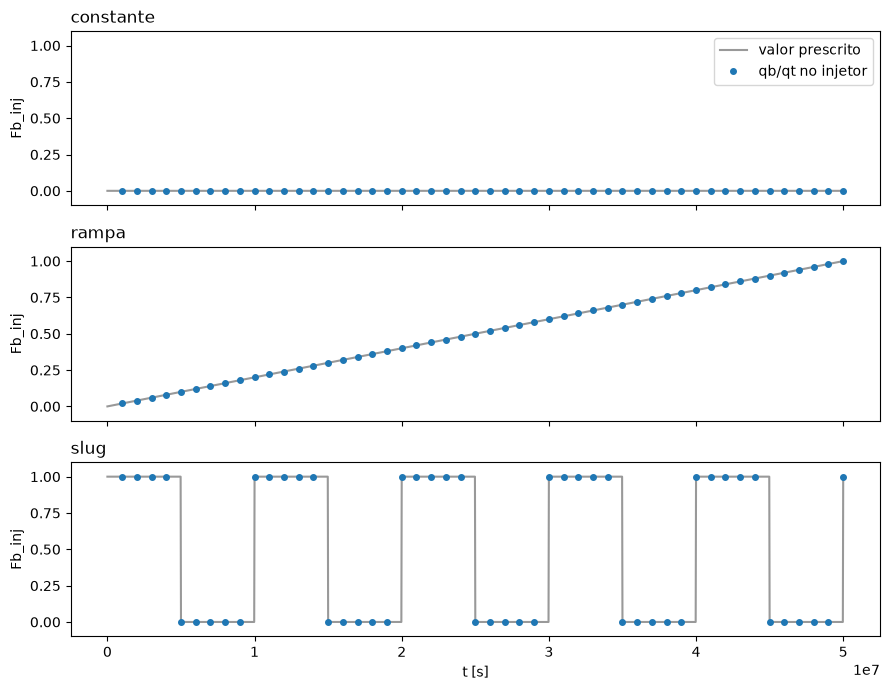

In [4]:
fig, axes = plt.subplots(len(results), 1, figsize=(9, 7), sharex=True)
t_fine = np.linspace(0, END_TIME, 2001)
for ax, (name, ds) in zip(axes, results.items()):
    t = ds.time.values
    applied = (ds.qb[:, INJ_CELLS].sum('cell') / ds.qt[:, INJ_CELLS].sum('cell')).values
    print(f'{name:>10}: erro máximo |qb/qt - prescrito| = {np.max(np.abs(applied - fb_prescribed(name, t))):.2e}')
    ax.plot(t_fine, fb_prescribed(name, t_fine), color='0.6', lw=1.5, label='valor prescrito')
    ax.plot(t, applied, 'o', ms=4, label='qb/qt no injetor')
    ax.set_ylabel('Fb_inj')
    ax.set_ylim(-0.1, 1.1)
    ax.set_title(name, loc='left')
axes[0].legend(loc='upper right')
axes[-1].set_xlabel('t [s]')
fig.tight_layout()

## Resposta do injetor

O injetor é controlado por pressão de fundo, então a vazão é a resposta que o solver calcula a cada passo. Ela muda com o `Fb_inj`, que altera a mobilidade perto do poço e a densidade da coluna de fluido no poço. O solver imprime a vazão no log a cada passo. Nesse intervalo a frente de saturação ainda não chega ao produtor, que produz só água nos três cenários.

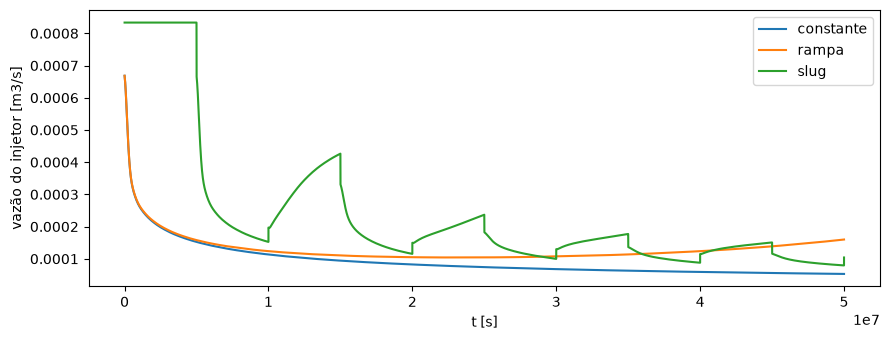

In [5]:
def injector_rate(run_dir):
    rate = {}
    t = None
    with open(run_dir / 'log.impesFoam2ph') as log:
        for line in log:
            if line.startswith('Time = '):
                t = float(line.split()[2])
            elif line.startswith('Well injector1 bhp = '):
                rate[t] = float(line.rsplit('=', 1)[1])
    return np.array(list(rate)), np.array(list(rate.values()))


fig, ax = plt.subplots(figsize=(9, 3.5))
for i, name in enumerate(results):
    t, q = injector_rate(EXPERIMENTS / f'2ph_{i:04d}')
    ax.plot(t, q, label=name)
ax.set_xlabel('t [s]')
ax.set_ylabel('vazão do injetor [m3/s]')
ax.legend()
fig.tight_layout()

## Saturação de água no instante final

Text(0.5, 0.98, 't = 5e+07 s')

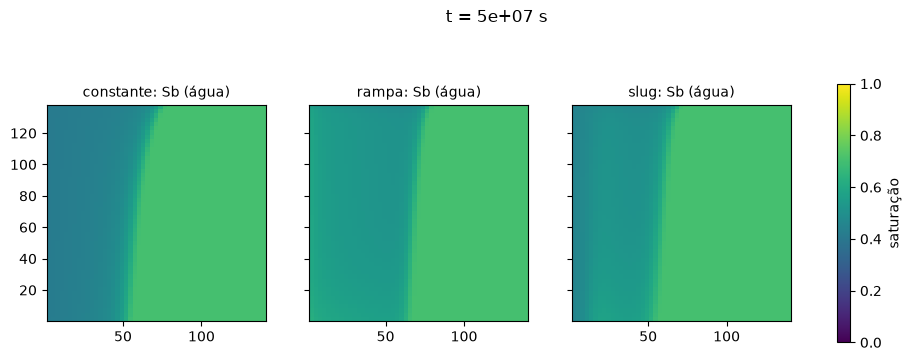

In [6]:
fig, axes = plt.subplots(1, len(results), figsize=(12, 4.2), sharex=True, sharey=True, squeeze=False)
for col, (name, ds) in enumerate(results.items()):
    x, y = ds.x.values, ds.y.values
    nx, ny = len(np.unique(np.round(x, 6))), len(np.unique(np.round(y, 6)))
    order = np.lexsort((x, y))
    for row, (field, label) in enumerate([('Sb', 'Sb (água)')]):
        ax = axes[row, col]
        values = ds[field].isel(time=-1).values[order].reshape(ny, nx)
        im = ax.imshow(values, origin='lower', extent=[x.min(), x.max(), y.min(), y.max()], vmin=0, vmax=1, cmap='viridis')
        ax.set_title(f'{name}: {label}', fontsize=10)
fig.colorbar(im, ax=axes, shrink=0.8, label='saturação')
fig.suptitle(f't = {END_TIME:g} s')